# Insurance Charges - Modelling
**Input:** `../data/model_ready/`

This notebook trains, compares, tunes, and evaluates regression models.

### Training the Baseline Model & Making Predictions

**The Objective:**
We will use Scikit-Learn's `LinearRegression` class to act as our baseline model. Because our dataset is relatively small (1,300 rows), this algorithm will use an exact mathematical solver (Singular Value Decomposition) to find the perfect Ordinary Least Squares (OLS) weights without needing iterative Gradient Descent.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
X_train = pd.read_csv('../data/model_ready/X_train.csv')
X_test = pd.read_csv('../data/model_ready/X_test.csv')
y_train = pd.read_csv('../data/model_ready/y_train.csv').squeeze()
y_test = pd.read_csv('../data/model_ready/y_test.csv').squeeze()

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


###  Model Evaluation & Diagnosing Overfitting

**The Objective:**
We must translate our model's mathematical accuracy into real-world business metrics. We will evaluate the model using three key performance indicators:
1. **$R^2$ (R-Squared):** The percentage of the target's variance explained by our features.
2. **MAE (Mean Absolute Error):** The average dollar amount our predictions are off by.
3. **RMSE (Root Mean Squared Error):** The average error, heavily penalized for massive outliers.

**The Methodology:**
To ensure our model actually learned human biology (and didn't just memorize the data), we will calculate these metrics for **both** the Training Set and the Testing Set. A large gap between these scores indicates **Overfitting**.

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
# we have to wrap MSE in numpy's square root function to get RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


print(" --- MODEL SCORECARD: TRAIN VS TEST ---\n")

print(f"{'Metric':<15} | {'Training Set':<20} | {'Testing Set':<20}")
print("-" * 65)
print(f"{'R-Squared (R²)':<15} | {train_r2:<20.4f} | {test_r2:<20.4f}")
print(f"{'MAE':<15} | ${train_mae:<19,.2f} | ${test_mae:<19,.2f}")
print(f"{'RMSE':<15} | ${train_rmse:<19,.2f} | ${test_rmse:<19,.2f}\n")

# Diagnostic check for Overfitting
gap = train_r2 - test_r2
print(f" Diagnostic: The Train/Test R² Gap is {gap:.4f}")
if gap > 0.08:
    print(" Model is memorizing data (Overfitting).")
else:
    print(" Gap is healthy. Model is generalizing well")

 --- MODEL SCORECARD: TRAIN VS TEST ---

Metric          | Training Set         | Testing Set         
-----------------------------------------------------------------
R-Squared (R²)  | 0.7351               | 0.8046              
MAE             | $0.28                | $0.27               
RMSE            | $0.45                | $0.40               

 Diagnostic: The Train/Test R² Gap is -0.0695
 Gap is healthy. Model is generalizing well


In [5]:
#the rmse and mae values are very small because we have used log charges, we can use np.exp to convert it into actual charges.

### Coefficient Interpretation

**The Objective:**
Linear Regression allows us to extract the exact mathematical weights assigned to each feature. By examining these coefficients, we can definitively prove which patient attributes drive hospital costs the highest.

*Note: Because our target variable (`charges`) was log-transformed, these coefficients represent the change in the natural log of the cost. Because our continuous variables were Standardized, their coefficients represent the change per standard deviation.*

In [6]:
model.intercept_#this stores the bias(the baseline hospital fee even if there is no age sex or smoking factor)

np.float64(8.493393498603078)

In [7]:
weights = model.coef_#this attribute stores the weights
features = X_train.columns
coefficients_df = pd.DataFrame({
    'Feature': features,
    'Weights': weights
})
coefficients_df

,Feature,Weights
0,age,0.464492
1,is_female,0.078117
2,bmi,0.004836
3,children,0.117271
4,is_smoker,1.451890
5,region_northwest,-0.045990
6,region_southeast,-0.121695
7,region_southwest,-0.103104
8,bmi_category_Normal,0.231686
9,bmi_category_Overweight,0.284918


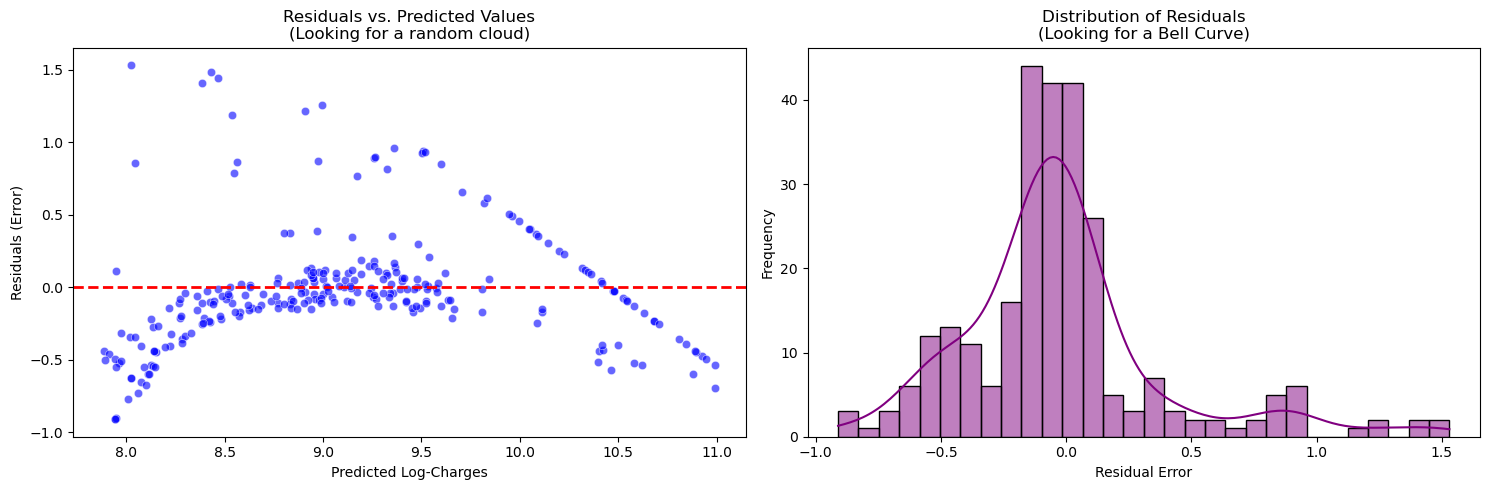

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the actual mistakes (Residuals) for the Test Set
# Error = True Value - Predicted Value
residuals = y_test - y_test_pred

# 2. Set up a wide canvas for two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ----------------------------------------------------
# PLOT 1: Residuals vs. Predicted (The Scatter Plot)
# ----------------------------------------------------
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6, ax=axes[0], color='blue')

# Draw the 'Perfect Prediction' baseline at Y=0
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)

axes[0].set_title('Residuals vs. Predicted Values\n(Looking for a random cloud)')
axes[0].set_xlabel('Predicted Log-Charges')
axes[0].set_ylabel('Residuals (Error)')


# ----------------------------------------------------
# PLOT 2: Residual Distribution (The Histogram)
# ----------------------------------------------------
# kde=True draws the smooth bell curve line over the bars
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=30)

axes[1].set_title('Distribution of Residuals\n(Looking for a Bell Curve)')
axes[1].set_xlabel('Residual Error')
axes[1].set_ylabel('Frequency')

# Show the plots!
plt.tight_layout()
plt.show()